### 1. KERNEL FUNTION FOR 

In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10



In [6]:


def prepare_points_euclidean(df):
    """Baseline: Standard Cartesian conversion"""
    r = df["distance_mm"].values / 1000.0
    theta = np.deg2rad(df["angle_deg"].values)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.vstack((x, y)).T

def prepare_points_kernel(df, distance_m, resolution):
    r = df["distance_mm"].values / 1000.0
    theta = np.deg2rad(df["angle_deg"].values)

    # Normalize factors
    res_factor = resolution / 360.0

    # Adaptive alpha
    if distance_m > 3.0:
        alpha = 0.3 + (0.3 * res_factor)
    else:
        alpha = 0.6 + (0.2 * res_factor)

    # Radial transform
    if distance_m > 3.5:
        r_prime = r ** alpha
    else:
        r_prime = np.log1p(r) ** alpha

   
    #Angular expansion ONLY for far distances
    
    if distance_m > 4.0:
        theta_prime = theta * (1.05 + 0.02 * (distance_m - 4.0))
    else:
        theta_prime = theta

    x_prime = r_prime * np.cos(theta_prime)
    y_prime = r_prime * np.sin(theta_prime)

    return np.vstack((x_prime, y_prime)).T

def run_dbscan(points, eps, min_samples):
    db = DBSCAN(eps=eps, min_samples=min_samples)
    return db.fit_predict(points)



def cluster_count(labels):
    """Number of detected clusters"""
    return len(set(labels)) - (1 if -1 in labels else 0)


def noise_percentage(labels):
    """Percentage of noise points"""
    return np.sum(labels == -1) / len(labels) * 100



GENERATING BEFORE/AFTER VISUALIZATIONS
(Fixed DBSCAN: eps=0.12, min_samples=3)

Processing: 0.25° @ 2/3/4 m
  Baseline: 12 clusters, 0.0% noise
  Kernel:   12 clusters, 0.0% noise

Processing: 0.50° @ 2/3/4m
  Baseline: 31 clusters, 9.4% noise
  Kernel:   12 clusters, 0.0% noise

Processing: 1° @ 2/3/4m
  Baseline: 6 clusters, 85.6% noise
  Kernel:   12 clusters, 0.0% noise

Processing: 2.00° @ 2/3/4m
  Baseline: 3 clusters, 91.7% noise
  Kernel:   12 clusters, 0.0% noise


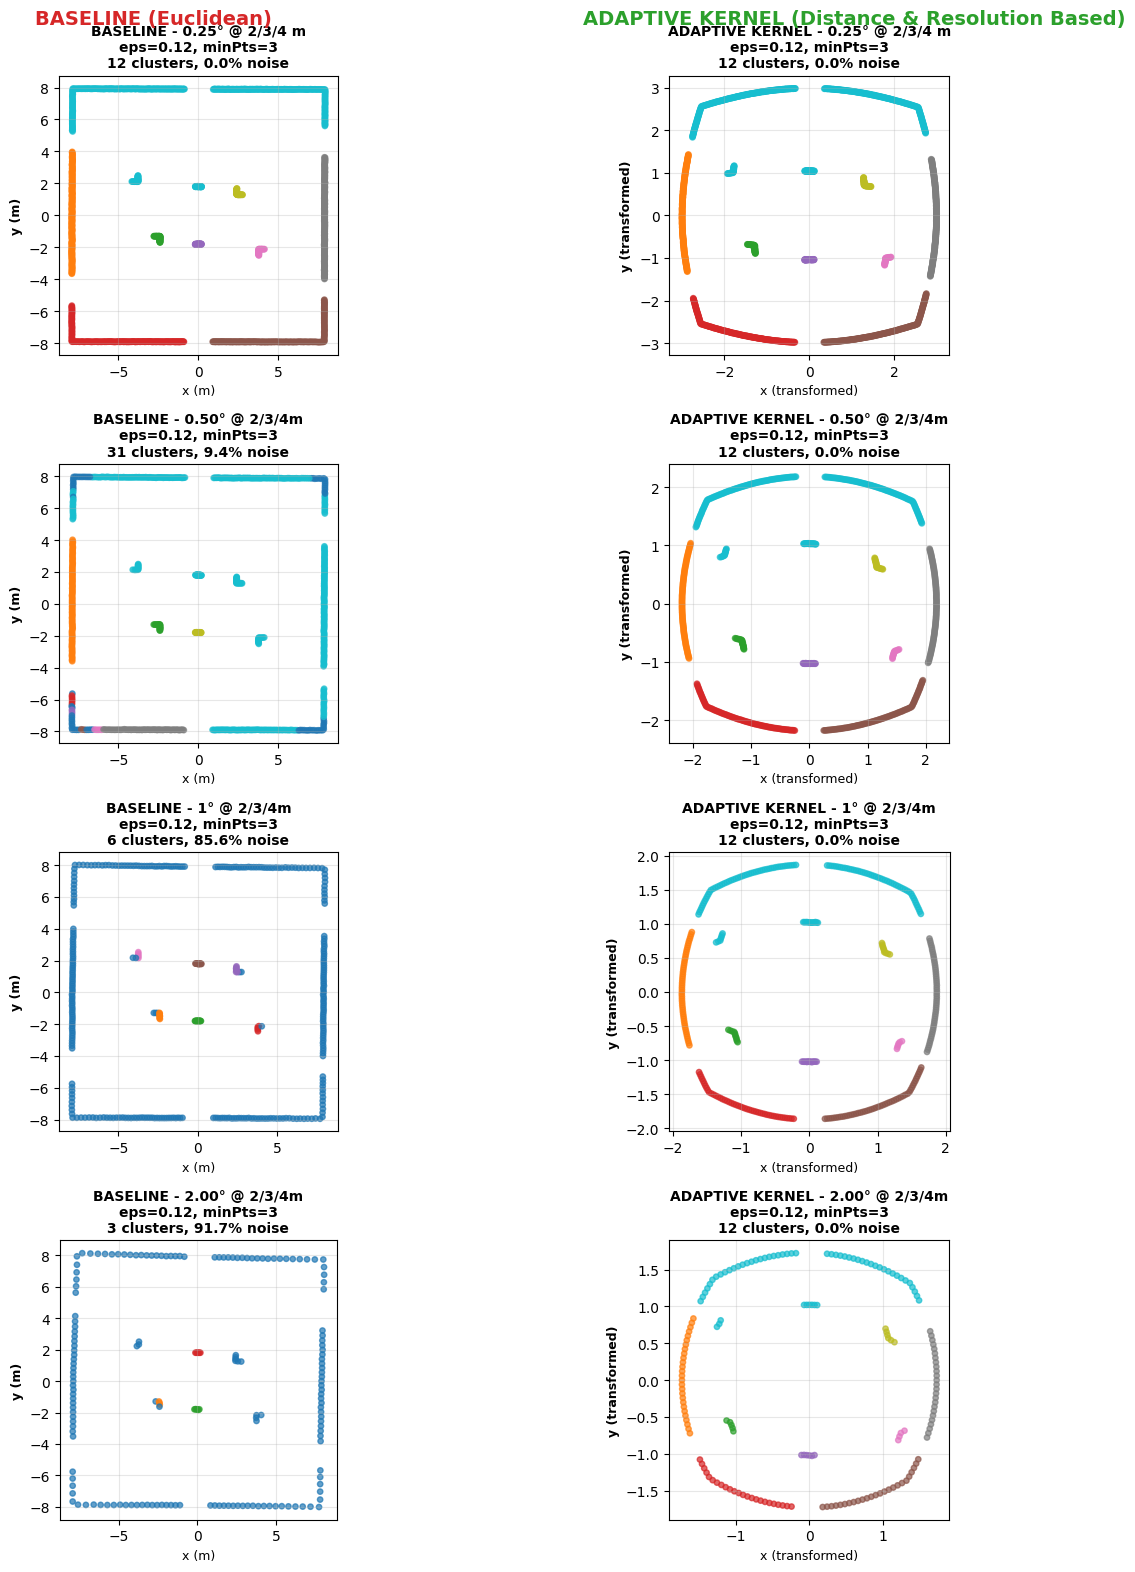

 Saved: phase3_before_after_FINAL.png


In [7]:

configs = [
    {'file': 'phase3_res025deg.csv', 'label': '0.25° @ 2/3/4 m', 'distance': 2/3/4, 'resolution': 1440},
    {'file': 'phase3_res050deg.csv', 'label': '0.50° @ 2/3/4m', 'distance': 2/3/4, 'resolution': 720},
    {'file': 'phase3_res100deg.csv', 'label': '1° @ 2/3/4m', 'distance': 2/3/4, 'resolution': 360},
    {'file': 'phase3_res200deg.csv', 'label': '2.00° @ 2/3/4m', 'distance': 2/3/4, 'resolution': 180}]

# Fixed DBSCAN parameters (same for all)
FIXED_EPS = 0.12
FIXED_MIN_SAMPLES = 3

print("=" * 70)
print("GENERATING BEFORE/AFTER VISUALIZATIONS")
print(f"(Fixed DBSCAN: eps={FIXED_EPS}, min_samples={FIXED_MIN_SAMPLES})")
print("=" * 70)

# Create figure
n_configs = len(configs)
fig, axes = plt.subplots(n_configs, 2, figsize=(14, 4*n_configs))

summary_data = []

for idx, config in enumerate(configs):
    print(f"\nProcessing: {config['label']}")
    
    # Load data
    df = pd.read_csv(config['file'])
    
    # BASELINE (fixed parameters)
    pts_baseline = prepare_points_euclidean(df)
    labels_baseline = run_dbscan(pts_baseline, eps=FIXED_EPS, min_samples=FIXED_MIN_SAMPLES)
    n_clusters_baseline = cluster_count(labels_baseline)
    noise_baseline = noise_percentage(labels_baseline)
    
    # KERNEL (adaptive kernel with distance and resolution parameters)
    pts_kernel = prepare_points_kernel(df, config['distance'], config['resolution'])
    labels_kernel = run_dbscan(pts_kernel, eps=FIXED_EPS, min_samples=FIXED_MIN_SAMPLES)
    n_clusters_kernel = cluster_count(labels_kernel)
    noise_kernel = noise_percentage(labels_kernel)
    
    # Calculate alpha value for display
    alpha_value = 0.35 + (0.45 / (1 + np.exp(-(config['distance'] - 2.5))))
    
    # Store for summary
    summary_data.append({
        'Configuration': config['label'],
        'Distance (m)': config['distance'],
        'Resolution': f"{config['resolution']}°",
        'Alpha': f"{alpha_value:.2f}",
        'Baseline Clusters': n_clusters_baseline,
        'Baseline Noise %': f"{noise_baseline:.1f}",
        'Kernel Clusters': n_clusters_kernel,
        'Kernel Noise %': f"{noise_kernel:.1f}",
        'Success': '✓' if n_clusters_kernel >= 4 else f'✗ ({n_clusters_kernel} clusters)'
    })
    
    # Plot BASELINE (left)
    axes[idx, 0].scatter(
        pts_baseline[:, 0], pts_baseline[:, 1],
        c=labels_baseline, cmap='tab10', s=15, vmin=-1, vmax=9, alpha=0.7
    )
    axes[idx, 0].set_title(
        f'BASELINE - {config["label"]}\n'
        f'eps={FIXED_EPS}, minPts={FIXED_MIN_SAMPLES}\n'
        f'{n_clusters_baseline} clusters, {noise_baseline:.1f}% noise',
        fontweight='bold', fontsize=10
    )
    axes[idx, 0].set_xlabel('x (m)', fontsize=9)
    axes[idx, 0].set_ylabel('y (m)', fontsize=9, fontweight='bold')
    axes[idx, 0].set_aspect('equal')
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Plot KERNEL (right)
    axes[idx, 1].scatter(
        pts_kernel[:, 0], pts_kernel[:, 1],
        c=labels_kernel, cmap='tab10', s=15, vmin=-1, vmax=9, alpha=0.7
    )
    axes[idx, 1].set_title(
        f'ADAPTIVE KERNEL - {config["label"]}\n'
        f'eps={FIXED_EPS}, minPts={FIXED_MIN_SAMPLES}\n'
        f'{n_clusters_kernel} clusters, {noise_kernel:.1f}% noise',
        fontweight='bold', fontsize=10
    )
    axes[idx, 1].set_xlabel('x (transformed)', fontsize=9)
    axes[idx, 1].set_ylabel('y (transformed)', fontsize=9, fontweight='bold')
    axes[idx, 1].set_aspect('equal')
    axes[idx, 1].grid(True, alpha=0.3)
    
    print(f"  Baseline: {n_clusters_baseline} clusters, {noise_baseline:.1f}% noise")
    print(f"  Kernel:   {n_clusters_kernel} clusters, {noise_kernel:.1f}% noise")

# Labels
fig.text(0.25, 0.98, 'BASELINE (Euclidean)', ha='center', va='top',
         fontsize=14, fontweight='bold', color='#d62728')
fig.text(0.75, 0.98, 'ADAPTIVE KERNEL (Distance & Resolution Based)', ha='center', va='top',
         fontsize=14, fontweight='bold', color='#2ca02c')

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('phase3_before_after_FINAL.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Saved: phase3_before_after_FINAL.png")



In [8]:



print("\n" + "=" * 70)
print(f"SUMMARY TABLE (Fixed DBSCAN: eps={FIXED_EPS}, min_samples={FIXED_MIN_SAMPLES})")
print("=" * 70)

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
summary_df.to_csv('phase3_summary_FINAL.csv', index=False)
print(" Saved: phase3_summary_FINAL.csv")




SUMMARY TABLE (Fixed DBSCAN: eps=0.12, min_samples=3)
  Configuration  Distance (m) Resolution Alpha  Baseline Clusters Baseline Noise %  Kernel Clusters Kernel Noise % Success
0.25° @ 2/3/4 m      0.166667      1440°  0.39                 12              0.0               12            0.0       ✓
 0.50° @ 2/3/4m      0.166667       720°  0.39                 31              9.4               12            0.0       ✓
    1° @ 2/3/4m      0.166667       360°  0.39                  6             85.6               12            0.0       ✓
 2.00° @ 2/3/4m      0.166667       180°  0.39                  3             91.7               12            0.0       ✓
 Saved: phase3_summary_FINAL.csv
